In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the cleaned file from Week 2
df = pd.read_csv("data/processed/AAPL_clean.csv", index_col="Date", parse_dates=True)


In [27]:
# Rebuild the columns from Week 2 that we'll build on this week

# How much did price move intraday? (High - Low)
df["Daily_Range"] = df["High"] - df["Low"]

# % change from Open to Close each day
df["OC_Change"] = (df["Close"] - df["Open"]) / df["Open"] * 100

# % change in Close from one day to the next
df["Daily_Return"] = df["Close"].pct_change()

# 20-day and 50-day moving averages (from Week 2 visualization)
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()
print(df[["Close", "Daily_Range", "OC_Change", "Daily_Return", "MA20", "MA50"]].tail())

                 Close  Daily_Range  OC_Change  Daily_Return        MA20  \
Date                                                                       
2026-06-17  295.950012     7.710022  -1.628717     -0.010994  303.609502   
2026-06-18  298.010010     4.950012  -0.033536      0.006961  303.397502   
2026-06-22  297.010010     5.660004  -0.100901     -0.003356  302.998503   
2026-06-23  294.299988     7.460022  -1.088936     -0.009124  302.272502   
2026-06-24  293.079987     6.760010  -0.771939     -0.004145  301.510002   

                  MA50  
Date                    
2026-06-17  287.842849  
2026-06-18  288.629816  
2026-06-22  289.365012  
2026-06-23  290.046207  
2026-06-24  290.728578  


In [28]:
# 5-day moving average — average of the last 5 closing prices
df["MA5"] = df["Close"].rolling(window=5).mean()

# Quick look at the three moving averages side by side
print(df[["Close", "MA5", "MA20", "MA50"]].dropna().tail(10))

                 Close         MA5        MA20        MA50
Date                                                      
2026-06-10  291.579987  300.447998  304.397000  283.805926
2026-06-11  295.630005  297.327997  304.235001  284.647399
2026-06-12  291.130005  294.085999  303.881001  285.362105
2026-06-15  296.420013  293.062000  303.690501  286.176816
2026-06-16  299.239990  294.800000  303.760501  286.989182
2026-06-17  295.950012  295.674005  303.609502  287.842849
2026-06-18  298.010010  296.150006  303.397502  288.629816
2026-06-22  297.010010  297.326007  302.998503  289.365012
2026-06-23  294.299988  296.902002  302.272502  290.046207
2026-06-24  293.079987  295.670001  301.510002  290.728578


In [29]:
# Ratio of 5-day to 20-day moving average

# Values > 1 → short-term trend above long-term (bullish)
# Values < 1 → short-term trend below long-term (bearish)
df["MA5_to_MA20"] = df["MA5"] / df["MA20"]

print(df[["MA5", "MA20", "MA5_to_MA20"]].dropna().tail(10))
print()
print(f"Average ratio: {df['MA5_to_MA20'].mean():.4f}")
print(f"Min ratio: {df['MA5_to_MA20'].min():.4f}")
print(f"Max ratio: {df['MA5_to_MA20'].max():.4f}")

                   MA5        MA20  MA5_to_MA20
Date                                           
2026-06-10  300.447998  304.397000     0.987027
2026-06-11  297.327997  304.235001     0.977297
2026-06-12  294.085999  303.881001     0.967767
2026-06-15  293.062000  303.690501     0.965002
2026-06-16  294.800000  303.760501     0.970501
2026-06-17  295.674005  303.609502     0.973863
2026-06-18  296.150006  303.397502     0.976112
2026-06-22  297.326007  302.998503     0.981279
2026-06-23  296.902002  302.272502     0.982233
2026-06-24  295.670001  301.510002     0.980631

Average ratio: 1.0045
Min ratio: 0.8873
Max ratio: 1.0686


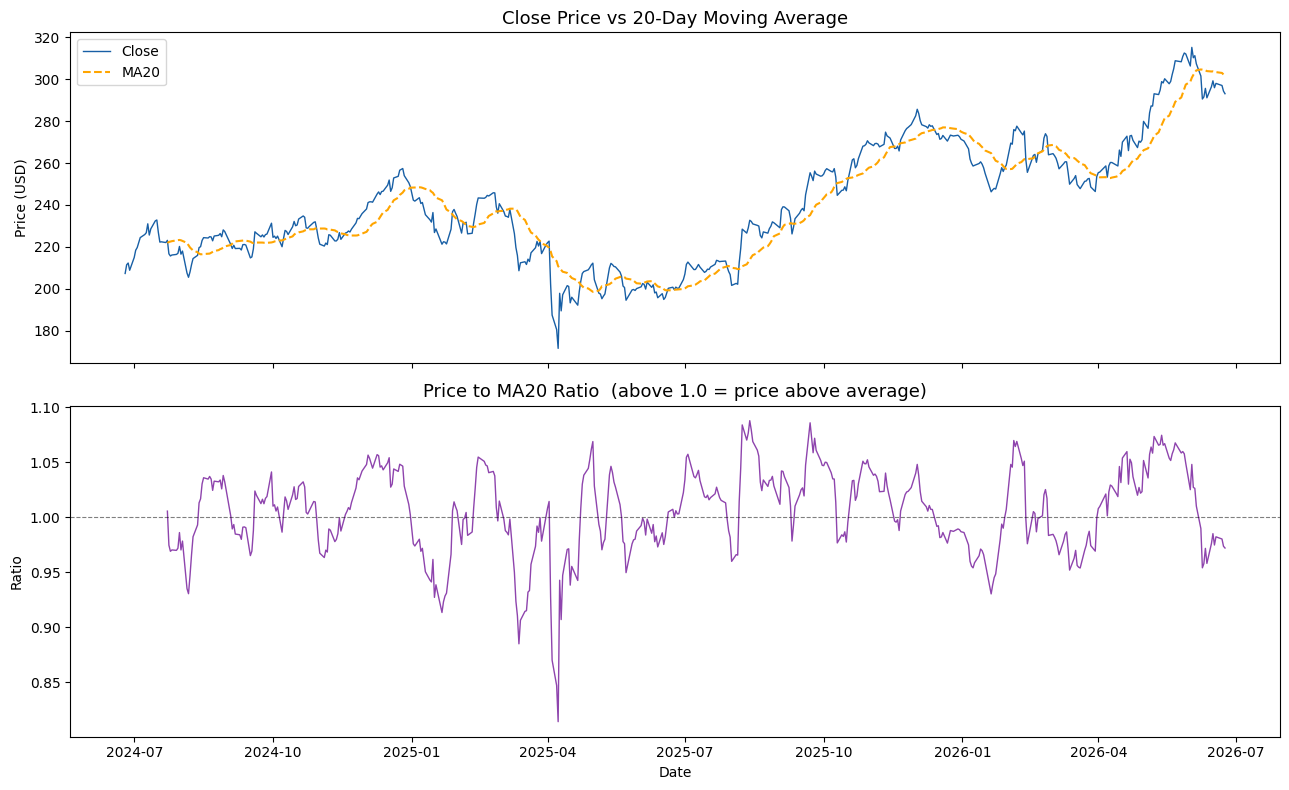

In [30]:
# Is today's price above or below its 20-day average?
df["Price_to_MA20"] = df["Close"] / df["MA20"]

# Let's visualize this to make it intuitive
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index, df["Close"], label="Close", linewidth=1, color="#185FA5")
axes[0].plot(df.index, df["MA20"], label="MA20", linewidth=1.5, color="orange", linestyle="--")
axes[0].set_title("Close Price vs 20-Day Moving Average", fontsize=13)
axes[0].legend()
axes[0].set_ylabel("Price (USD)")

axes[1].plot(df.index, df["Price_to_MA20"], linewidth=1, color="#8E44AD")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[1].set_title("Price to MA20 Ratio  (above 1.0 = price above average)", fontsize=13)
axes[1].set_ylabel("Ratio")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [31]:
# Confirm Daily_Return exists from our rebuild step
print("Daily_Return exists:", "Daily_Return" in df.columns)
print(df["Daily_Return"].describe().round(4))

Daily_Return exists: True
count    500.0000
mean       0.0008
std        0.0176
min       -0.0925
25%       -0.0067
50%        0.0012
75%        0.0090
max        0.1533
Name: Daily_Return, dtype: float64


In [32]:
# Shift Daily_Return by 1 row — today's Lag1_Return is yesterday's Daily_Return
df["Lag1_Return"] = df["Daily_Return"].shift(1)
# we do shift(1) here note if we do shift(-1) may lead to data leakage 
# Verify: Lag1_Return on row N should equal Daily_Return on row N-1
print(df[["Daily_Return", "Lag1_Return"]].dropna().head(8))

            Daily_Return  Lag1_Return
Date                                 
2024-06-27      0.003986     0.019993
2024-06-28     -0.016254     0.003986
2024-07-01      0.029105    -0.016254
2024-07-02      0.016240     0.029105
2024-07-03      0.005811     0.016240
2024-07-05      0.021620     0.005811
2024-07-08      0.006539     0.021620
2024-07-09      0.003775     0.006539


In [33]:
# Shift by 2 rows — today's Lag2_Return is two days ago's Daily_Return
df["Lag2_Return"] = df["Daily_Return"].shift(2)

print(df[["Daily_Return", "Lag1_Return", "Lag2_Return"]].dropna().head(8))

            Daily_Return  Lag1_Return  Lag2_Return
Date                                              
2024-06-28     -0.016254     0.003986     0.019993
2024-07-01      0.029105    -0.016254     0.003986
2024-07-02      0.016240     0.029105    -0.016254
2024-07-03      0.005811     0.016240     0.029105
2024-07-05      0.021620     0.005811     0.016240
2024-07-08      0.006539     0.021620     0.005811
2024-07-09      0.003775     0.006539     0.021620
2024-07-10      0.018803     0.003775     0.006539


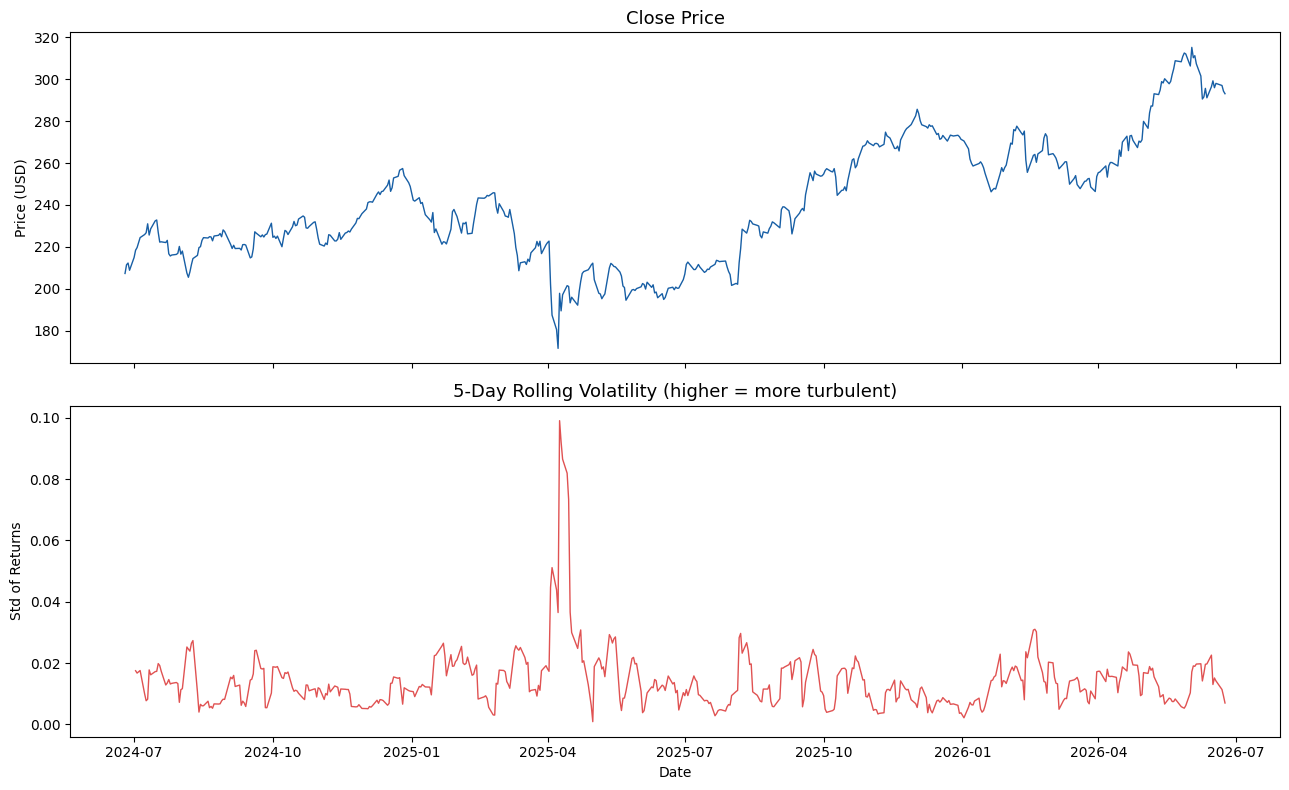

In [34]:
# Standard deviation of daily returns over last 5 days
df["Volatility_5d"] = df["Daily_Return"].rolling(window=5).std()

# Visualize: compare volatility to price
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index, df["Close"], linewidth=1, color="#185FA5")
axes[0].set_title("Close Price", fontsize=13)
axes[0].set_ylabel("Price (USD)")

axes[1].plot(df.index, df["Volatility_5d"], linewidth=1, color="#E05252")
axes[1].set_title("5-Day Rolling Volatility (higher = more turbulent)", fontsize=13)
axes[1].set_ylabel("Std of Returns")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

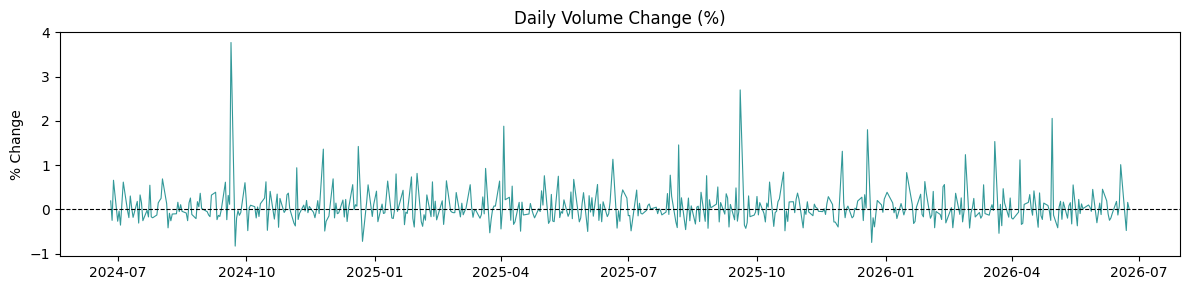

In [35]:
df['Volume_Change'] = df['Volume'].pct_change()

plt.figure(figsize=(12, 3))
plt.plot(df.index, df['Volume_Change'], color='teal', linewidth=0.8, alpha=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Daily Volume Change (%)')
plt.ylabel('% Change')
plt.tight_layout()
plt.show()

In [36]:
feature_cols = [
    "Daily_Return",
    "MA5",
    "MA5_to_MA20",
    "Price_to_MA20",
    "Lag1_Return",
    "Lag2_Return",
    "Volatility_5d",
    "Volume_Change"
]

print("All 8 features — last 5 rows:")
print(df[feature_cols].dropna().tail().round(4))

print("Any missing values?")
print(df[feature_cols].isnull().sum())

All 8 features — last 5 rows:
            Daily_Return      MA5  MA5_to_MA20  Price_to_MA20  Lag1_Return  \
Date                                                                         
2026-06-17       -0.0110  295.674       0.9739         0.9748       0.0095   
2026-06-18        0.0070  296.150       0.9761         0.9822      -0.0110   
2026-06-22       -0.0034  297.326       0.9813         0.9802       0.0070   
2026-06-23       -0.0091  296.902       0.9822         0.9736      -0.0034   
2026-06-24       -0.0041  295.670       0.9806         0.9720      -0.0091   

            Lag2_Return  Volatility_5d  Volume_Change  
Date                                                   
2026-06-17       0.0182         0.0152         0.0720  
2026-06-18       0.0095         0.0142         1.0110  
2026-06-22      -0.0110         0.0114        -0.4779  
2026-06-23       0.0070         0.0093         0.1589  
2026-06-24      -0.0034         0.0070         0.0168  
Any missing values?
Daily_Retur

In [37]:
# shift(-1) gives us tomorrow's closing price at today's row
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

print(df[['Close', 'Target']].tail(8))

                 Close  Target
Date                          
2026-06-12  291.130005       1
2026-06-15  296.420013       1
2026-06-16  299.239990       0
2026-06-17  295.950012       1
2026-06-18  298.010010       0
2026-06-22  297.010010       0
2026-06-23  294.299988       0
2026-06-24  293.079987       0


Target
1    273
0    228
Name: count, dtype: int64


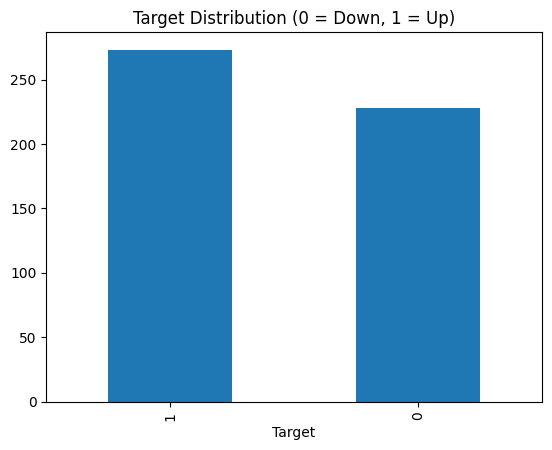

In [38]:
# Count how many Up days (1) and Down days (0) we have
print(df["Target"].value_counts())

# Visualize the distribution
df["Target"].value_counts().plot(
    kind="bar",
    title="Target Distribution (0 = Down, 1 = Up)"
)

plt.show()

In [39]:
# Remove rows that contain missing values
df_ml = df[feature_cols + ["Target"]].dropna()

print("Rows before:", len(df))
print("Rows after :", len(df_ml))

Rows before: 501
Rows after : 482


In [40]:
print("Final dataset shape:", df_ml.shape)
print()
print("Feature columns and types:")
print(df_ml.dtypes)
print()
print("Summary stats:")
print(df_ml.describe().round(4))

Final dataset shape: (482, 9)

Feature columns and types:
Daily_Return     float64
MA5              float64
MA5_to_MA20      float64
Price_to_MA20    float64
Lag1_Return      float64
Lag2_Return      float64
Volatility_5d    float64
Volume_Change    float64
Target             int64
dtype: object

Summary stats:
       Daily_Return       MA5  MA5_to_MA20  Price_to_MA20  Lag1_Return  \
count      482.0000  482.0000     482.0000       482.0000     482.0000   
mean         0.0007  240.5204       1.0045         1.0058       0.0007   
std          0.0176   28.2466       0.0299         0.0385       0.0176   
min         -0.0925  185.3268       0.8873         0.8139      -0.0925   
25%         -0.0067  219.9124       0.9849         0.9801      -0.0067   
50%          0.0011  234.8189       1.0064         1.0083       0.0011   
75%          0.0081  261.3670       1.0272         1.0342       0.0081   
max          0.1533  311.3860       1.0686         1.0880       0.1533   

       Lag2_Return  

In [41]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


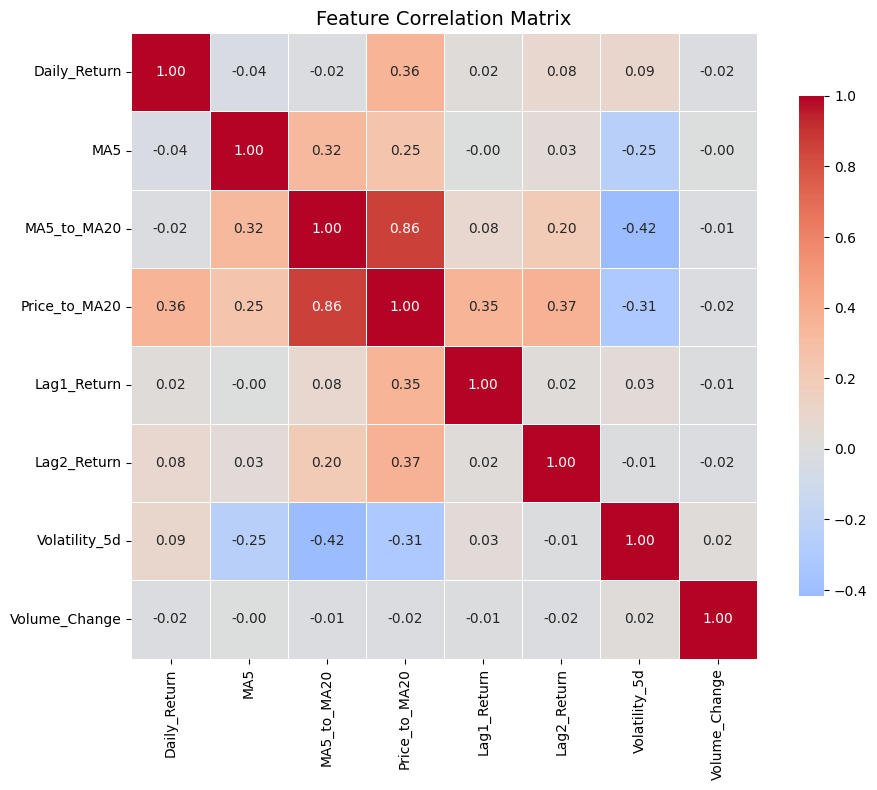

In [42]:
import seaborn as sns

corr = df_ml[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
os.makedirs("data/processed", exist_ok=True)
df_ml.to_csv("data/processed/AAPL_features.csv")

print(df_ml.tail())

            Daily_Return         MA5  MA5_to_MA20  Price_to_MA20  Lag1_Return  \
Date                                                                            
2026-06-17     -0.010994  295.674005     0.973863       0.974772     0.009513   
2026-06-18      0.006961  296.150006     0.976112       0.982243    -0.010994   
2026-06-22     -0.003356  297.326007     0.981279       0.980236     0.006961   
2026-06-23     -0.009124  296.902002     0.982233       0.973625    -0.003356   
2026-06-24     -0.004145  295.670001     0.980631       0.972041    -0.009124   

            Lag2_Return  Volatility_5d  Volume_Change  Target  
Date                                                           
2026-06-17     0.018171       0.015158       0.071994       1  
2026-06-18     0.009513       0.014208       1.011042       0  
2026-06-22    -0.010994       0.011390      -0.477911       0  
2026-06-23     0.006961       0.009281       0.158891       0  
2026-06-24    -0.003356       0.006994       0.0

In [44]:
df_check = pd.read_csv(
    "data/processed/AAPL_features.csv",
    index_col="Date",
    parse_dates=True
)

print(df_check.shape)
print(df_check.isnull().sum().sum())
print(df_check["Target"].value_counts())


(482, 9)
0
Target
1    259
0    223
Name: count, dtype: int64


In [45]:
# RSI (Relative Strength Index) — momentum indicator
delta = df["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

print(df[["Close", "RSI_14"]].dropna().tail(10))

                 Close     RSI_14
Date                             
2026-06-10  291.579987  40.111221
2026-06-11  295.630005  41.530978
2026-06-12  291.130005  34.185619
2026-06-15  296.420013  40.194341
2026-06-16  299.239990  40.488281
2026-06-17  295.950012  36.785837
2026-06-18  298.010010  39.069563
2026-06-22  297.010010  42.187513
2026-06-23  294.299988  30.408686
2026-06-24  293.079987  32.688418


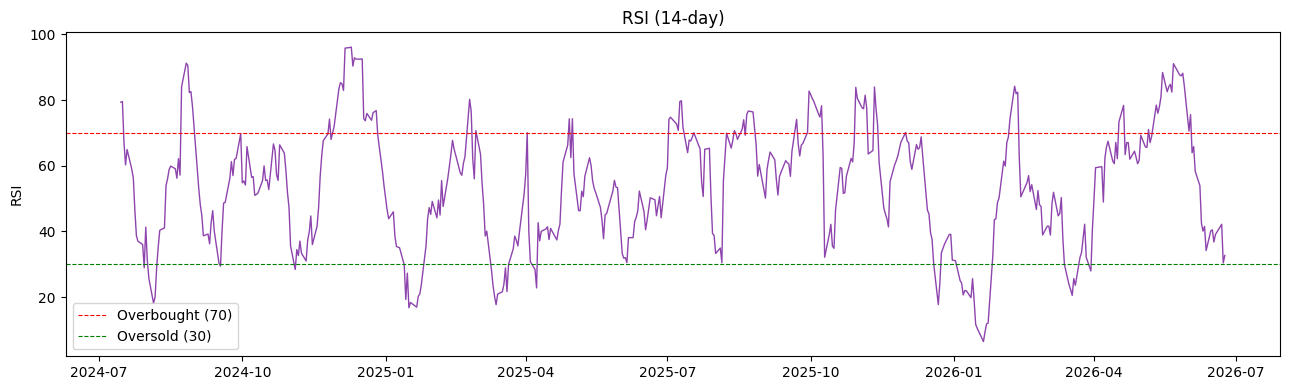

In [46]:
plt.figure(figsize=(13, 4))
plt.plot(df.index, df["RSI_14"], color="#8E44AD", linewidth=1)
plt.axhline(70, color="red", linestyle="--", linewidth=0.8, label="Overbought (70)")
plt.axhline(30, color="green", linestyle="--", linewidth=0.8, label="Oversold (30)")
plt.title("RSI (14-day)")
plt.ylabel("RSI")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
df["Close_to_MA50"] = df["Close"] / df["MA50"]

print(df[["Close", "MA50", "Close_to_MA50"]].dropna().tail(10))

                 Close        MA50  Close_to_MA50
Date                                             
2026-06-10  291.579987  283.805926       1.027392
2026-06-11  295.630005  284.647399       1.038583
2026-06-12  291.130005  285.362105       1.020213
2026-06-15  296.420013  286.176816       1.035793
2026-06-16  299.239990  286.989182       1.042687
2026-06-17  295.950012  287.842849       1.028165
2026-06-18  298.010010  288.629816       1.032499
2026-06-22  297.010010  289.365012       1.026420
2026-06-23  294.299988  290.046207       1.014666
2026-06-24  293.079987  290.728578       1.008088


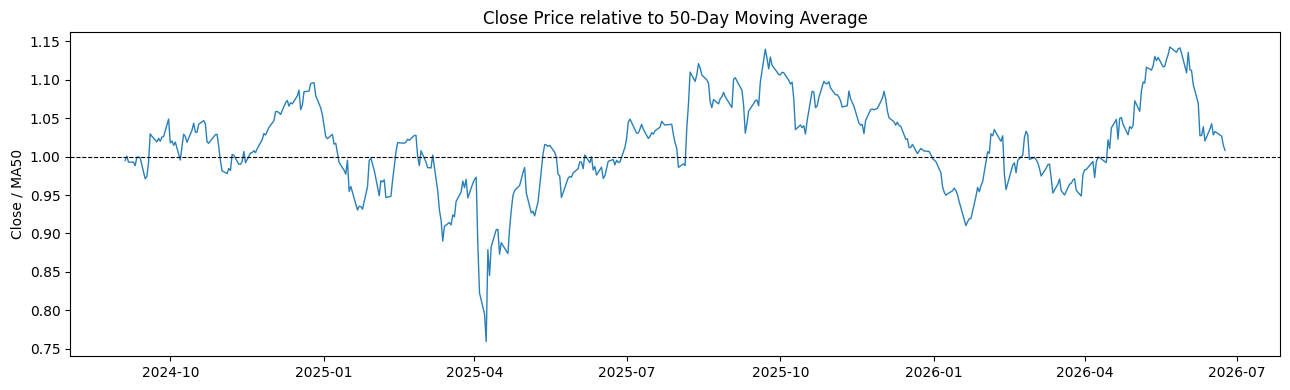

In [48]:
plt.figure(figsize=(13, 4))
plt.plot(df.index, df["Close_to_MA50"], color="#2980B9", linewidth=1)
plt.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
plt.title("Close Price relative to 50-Day Moving Average")
plt.ylabel("Close / MA50")
plt.tight_layout()
plt.show()

In [49]:
feature_cols = feature_cols + ["RSI_14", "Close_to_MA50"]

df_ml = df[feature_cols + ["Target"]].dropna()

print("Final shape with new features:", df_ml.shape)
print(df_ml[feature_cols].isnull().sum())

df_ml.to_csv("data/processed/AAPL_features.csv")
print("Re-saved successfully")

Final shape with new features: (452, 11)
Daily_Return     0
MA5              0
MA5_to_MA20      0
Price_to_MA20    0
Lag1_Return      0
Lag2_Return      0
Volatility_5d    0
Volume_Change    0
RSI_14           0
Close_to_MA50    0
dtype: int64
Re-saved successfully
